In [107]:
import glob
import os
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
from IPython.display import display

import ldparser
from ldparser import ldData

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import silhouette_score

In [108]:
ld_data = glob.glob("raw_data/*.ld")

channel_tuple_mapping = {
    'Steering Angle': 'steering_angle',
    'Throttle Pos': 'throttle_pos',
    'Brake Pos': 'brake_pos',
    'Engine RPM': 'engine_rpm',
    'Wheel Angular Speed FL': 'speed_fl',
}

In [109]:
master_feature_liste = []

for ld_file in ld_data:
    timestamp_in_seconds = []
    ldx_file = ld_file.replace('.ld', '.ldx')

    # LDX-Datei einlesen und Zeitstempel der Beacons extrahieren
    try: 
        ldx_file_tree = ET.parse(ldx_file)
        ldx_file_root = ldx_file_tree.getroot()

        for beacon in ldx_file_root.findall('.//MarkerGroup[@Name="Beacons"]/Marker'):
            time_node = beacon.get('Time')

            if time_node is not None:
                time_node_in_seconds = float(time_node) / 1000000.0
                timestamp_in_seconds.append(time_node_in_seconds)
    except Exception as e:
        print(f"\n{e}")

    # LD-Datei einlesen und relevante Kanäle extrahieren
    telemetry_tuple = ldData.fromfile(ld_file)
    channel_data = {}
    for ld_name, htf_name in channel_tuple_mapping.items():
        
        if ld_name in telemetry_tuple:
            channel_object = telemetry_tuple[ld_name]
            channel_data[htf_name] = pd.Series(data=channel_object.data, index=np.arange(len(channel_object.data)) / getattr(channel_object, 'freq'))

            df_telemetry = pd.DataFrame(channel_data)

        else:
            print(f"\n{e}")
    

    for i in range(len(timestamp_in_seconds) - 1):
        # Zeit der Fahrer pro Rundenabschnitt extrahieren
        start_time = timestamp_in_seconds[i]
        end_time = timestamp_in_seconds[i + 1]
        
        curve_data = df_telemetry[(df_telemetry.index >= start_time) & (df_telemetry.index < end_time)]
        if curve_data.empty:
            continue

        # Fahrer-ID aus dem Dateinamen extrahieren
        file_name = os.path.basename(ld_file)
        data_name_parted = file_name.split('_&_')
        
        if len(data_name_parted) >= 3:
            driver_id = data_name_parted[2]
        else:
            driver_id = file_name
            
        feature = {
            'Fahrer_ID': driver_id,
            'Segment_Nummer': i + 1,

            # Die biometrischen Features (Mensch)
            'lenkung_unruhe': curve_data['steering_angle'].var() if 'steering_angle' in curve_data else 0,
            'gas_schnitt': curve_data['throttle_pos'].mean() if 'throttle_pos' in curve_data else 0,
            'gas_streuung': curve_data['throttle_pos'].var() if 'throttle_pos' in curve_data else 0,
            'brems_haerte': curve_data['brake_pos'].max() if 'brake_pos' in curve_data else 0,
            'brems_streuung': curve_data['brake_pos'].var() if 'brake_pos' in curve_data else 0,
            'drehzahl_schnitt': curve_data['engine_rpm'].mean() if 'engine_rpm' in curve_data else 0,

            # Die Physik-Kontext
            'geschw_schnitt': curve_data['speed_fl'].mean() if 'speed_fl' in curve_data else 0,
            'geschw_streuung': curve_data['speed_fl'].var() if 'speed_fl' in curve_data else 0,
        }
        master_feature_liste.append(feature)

df_master_ml = pd.DataFrame(master_feature_liste)
display(df_master_ml)

,Fahrer_ID,Segment_Nummer,lenkung_unruhe,gas_schnitt,gas_streuung,brems_haerte,brems_streuung,drehzahl_schnitt,geschw_schnitt,geschw_streuung
0,KEPD180,1,2178.967979,30.276085,491.698427,62.645714,169.586153,6488.723064,82.995369,1066.030572
1,KEPD180,2,1512.884081,33.840939,568.319213,64.275714,198.032419,6484.206040,84.985958,900.294745
2,KEPD180,3,1234.882773,33.025186,513.401169,88.424286,225.734819,6655.333700,87.990162,741.064056
3,KEPD180,4,2143.910024,35.785651,578.534677,76.600000,230.704524,5815.048329,85.629013,799.410694
4,KEPD180,5,1242.765028,35.532091,650.264238,81.305714,232.195841,5821.844547,85.949598,845.635448
...,...,...,...,...,...,...,...,...,...,...
139,OLOT290,2,810.927067,35.149509,1178.952369,47.760000,51.999980,6157.233307,49.617043,760.788759
140,OLOT290,3,544.069920,32.932558,1116.468451,59.605000,89.706292,5873.094271,63.525495,441.321581
141,OLOT290,4,553.658083,37.736827,1525.412639,50.415000,79.794298,5703.443397,60.574651,474.290883
142,OLOT290,5,463.452172,35.806458,1350.972643,52.485000,66.558296,5982.268264,64.756866,439.070692


In [110]:
# =========================================================================
# HEBEL 1: DIE RUNDEN-SÄUBERUNG (AUTOMATISCHE OUTLIER-FILTERUNG PER FAHRER)
# =========================================================================
import pandas as pd
import numpy as np

print(f"[Data-Cleaning] Datensatz VOR der Bereinigung: {df_master_ml.shape[0]} Zeilen")

# Sicherheitskopie für den Vorher-Nachher-Vergleich
df_vorher = df_master_ml.copy()

# Liste für die bereinigten Datenpakete der einzelnen Fahrer
bereinigte_fahrer_dfs = []

# Wir gehen jeden Fahrer einzeln durch, um seine persönliche Baseline zu schützen
for fahrer_id, fahrer_gruppe in df_master_ml.groupby('Fahrer_ID'):
    
    # --- ANSATZ A: Falls du eine explizite Rundenzeit-Spalte im DataFrame hast ---
    # (Ersetze 'Rundenzeit' durch deinen exakten Spaltennamen, falls vorhanden)
    if 'Rundenzeit' in fahrer_gruppe.columns:
        persoenliche_bestzeit = fahrer_gruppe['Rundenzeit'].min()
        # Maximal 5% Abweichung von der persönlichen Bestzeit erlaubt (In-/Out-Laps fliegen raus)
        toleranz_grenze = persoenliche_bestzeit * 1.05 
        fahrer_gruppe = fahrer_gruppe[fahrer_gruppe['Rundenzeit'] <= toleranz_grenze]
        
    # --- ANSATZ B: Statistischer IQR-Filter auf fahrphysikalische Kern-Features ---
    # Falls keine Rundenzeit da ist, filtern wir extreme Anomalien (z.B. Stehen in der Box, Boxenrunde)
    # über die Streuung von Vollgas-Anteil und Fliehkräften aus.
    else:
        # Wir picken uns 2-3 Kernfeatures heraus, die bei einer Boxenrunde komplett einbrechen
        fokus_features = [ 
            'brems_streuung', 
            'gas_streuung', 
            'geschw_streuung',
        ]
        
        for col in fokus_features:
            if col in fahrer_gruppe.columns:
                # Berechne das 25%- und 75%-Quartil des jeweiligen Fahrers
                Q1 = fahrer_gruppe[col].quantile(0.25)
                Q3 = fahrer_gruppe[col].quantile(0.75)
                IQR = Q3 - Q1
                
                # Wer mehr als 1.5 * IQR nach unten abweicht (z.B. kaum Gas gegeben, weil Boxenrunde), fliegt raus
                untere_grenze = Q1 - 1.5 * IQR
                # Wer extrem nach oben abweicht (z.B. Messfehler), fliegt ebenfalls raus
                obere_grenze = Q3 + 1.5 * IQR
                
                fahrer_gruppe = fahrer_gruppe[(fahrer_gruppe[col] >= untere_grenze) & (fahrer_gruppe[col] <= obere_grenze)]
                
    bereinigte_fahrer_dfs.append(fahrer_gruppe)

# Alle bereinigten Fahrer-Pakete wieder zu einem großen Master-DataFrame zusammenbauen
df_master_ml = pd.concat(bereinigte_fahrer_dfs, ignore_index=True)

# Abschluss-Report ausgeben
entfernte_runden = df_vorher.shape[0] - df_master_ml.shape[0]
print(f"[Data-Cleaning] Datensatz NACH der Bereinigung: {df_master_ml.shape[0]} Zeilen")
print(f"[Data-Cleaning] Erfolg! {entfernte_runden} unrepräsentative Runden/Ausreißer wurden eliminiert.")

[Data-Cleaning] Datensatz VOR der Bereinigung: 144 Zeilen
[Data-Cleaning] Datensatz NACH der Bereinigung: 116 Zeilen
[Data-Cleaning] Erfolg! 28 unrepräsentative Runden/Ausreißer wurden eliminiert.



--- STATISTISCHER REPORT FÜR DEINE THESIS ---
Hauptkomponente 1 (PC1): Erklärt 46.0% der gesamten Fahrer-Unterschiede.
Hauptkomponente 2 (PC2): Erklärt 16.7% der gesamten Fahrer-Unterschiede.
Hauptkomponente 3 (PC3): Erklärt 12.7% der gesamten Fahrer-Unterschiede.
-> Gesamte erklärte Wahrheit im 3D-Raum: 75.5%
-------------------------------------------------



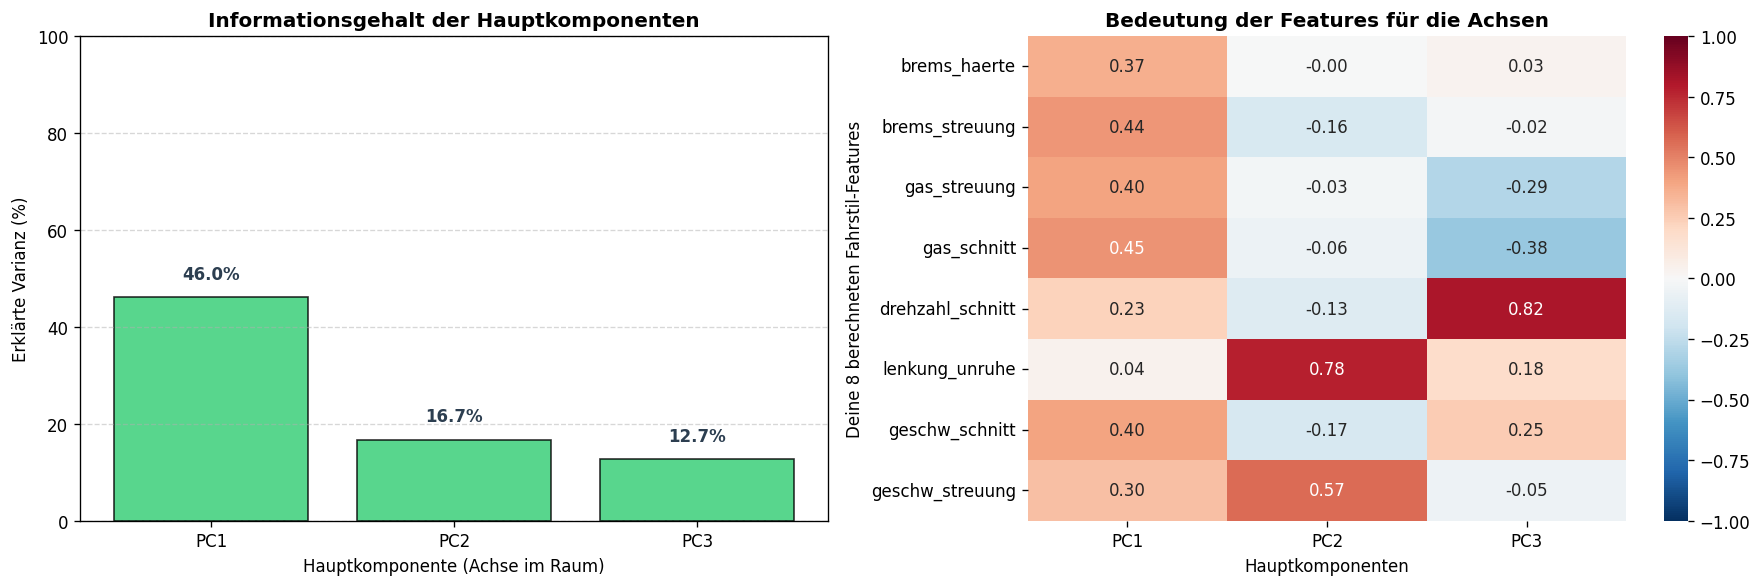

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

try:
    # 1. Reine Feature-Matrix isolieren (Metadaten weglassen)
    spalten_fuer_pca = [ 
        'brems_haerte', 'brems_streuung', 
        'gas_streuung', 'gas_schnitt', 
        'drehzahl_schnitt', 'lenkung_unruhe', 
        'geschw_schnitt', 'geschw_streuung',
    ]
    
    # Prüfen, ob alle Spalten da sind
    vorhandene_features = [f for f in spalten_fuer_pca if f in df_master_ml.columns]
    X_pca_input = df_master_ml[vorhandene_features]

    # 2. Skalierung (Absolut Pflicht vor einer PCA!)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_pca_input)

    # 3. PCA berechnen (Wir schauen uns die ersten 3 Hauptkomponenten an)
    pca = PCA(n_components=3)
    X_projected = pca.fit_transform(X_scaled)
    var_exp = pca.explained_variance_ratio_

    # --- TEXT-REPORT FÜR DEINE UNTERLAGEN ---
    print("\n--- STATISTISCHER REPORT FÜR DEINE THESIS ---")
    for idx, anteil in enumerate(var_exp):
        print(f"Hauptkomponente {idx+1} (PC{idx+1}): Erklärt {anteil*100:.1f}% der gesamten Fahrer-Unterschiede.")
    print(f"-> Gesamte erklärte Wahrheit im 3D-Raum: {sum(var_exp)*100:.1f}%")
    print("-------------------------------------------------\n")

    # --- GRAFIK 1: DER SCREE-PLOT (Erklärte Varianz) ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), dpi=120)
    
    komponenten_labels = [f"PC{i+1}" for i in range(len(var_exp))]
    bars = ax1.bar(komponenten_labels, var_exp * 100, color='#2ecc71', edgecolor='k', alpha=0.8)
    ax1.set_title("Informationsgehalt der Hauptkomponenten", fontweight='bold', fontsize=12)
    ax1.set_xlabel("Hauptkomponente (Achse im Raum)")
    ax1.set_ylabel("Erklärte Varianz (%)")
    ax1.set_ylim(0, 100)
    ax1.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Prozentzahlen auf die Säulen schreiben
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 3, f"{height:.1f}%", 
                 ha='center', va='bottom', fontweight='bold', color='#2c3e50')

    # --- GRAFIK 2: FEATURE LOADINGS HEATMAP (Deine Feature-Vorstellung!) ---
    # Hier wird berechnet, wie stark jedes deiner 8 Features auf die Achsen abfärbt
    loadings = pd.DataFrame(
        pca.components_.T, 
        columns=[f'PC1', f'PC2', f'PC3'], 
        index=vorhandene_features
    )
    
    sns.heatmap(loadings, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt=".2f", ax=ax2, cbar=True)
    ax2.set_title("Bedeutung der Features für die Achsen", fontweight='bold', fontsize=12)
    ax2.set_ylabel("Deine 8 berechneten Fahrstil-Features")
    ax2.set_xlabel("Hauptkomponenten")
    
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"\n[FAIL] Fehler bei der Varianz-Analyse: {e}")

In [112]:
import pandas as pd
import glob
import os

csv_data = glob.glob('processed_data/*.csv')
all_driver_data = []

for data_file in csv_data:
    dateiname = os.path.basename(data_file)
    probanden_id = dateiname.split('_')[0] 
    
    df_temp = pd.read_csv(data_file, skiprows=7)
    
    df_temp['Fahrer_ID'] = probanden_id
    
    all_driver_data.append(df_temp)

# Alle Tabellen zu einem riesigen Master-DataFrame zusammenkleben
df_master_ml_real = pd.concat(all_driver_data, ignore_index=True)

print(f"[OK] {len(csv_data)} Probanden-Dateien erfolgreich geladen!")
print(f"-> Gefundene IDs: {df_master_ml_real['Fahrer_ID'].unique()}")

[OK] 10 Probanden-Dateien erfolgreich geladen!
-> Gefundene IDs: <StringArray>
['TOINZ27000', 'INBWZ11002', 'MAAKZ19001', 'CHIPZ26000', 'PASZZ20000',
 'MAMCZ06001']
Length: 6, dtype: str


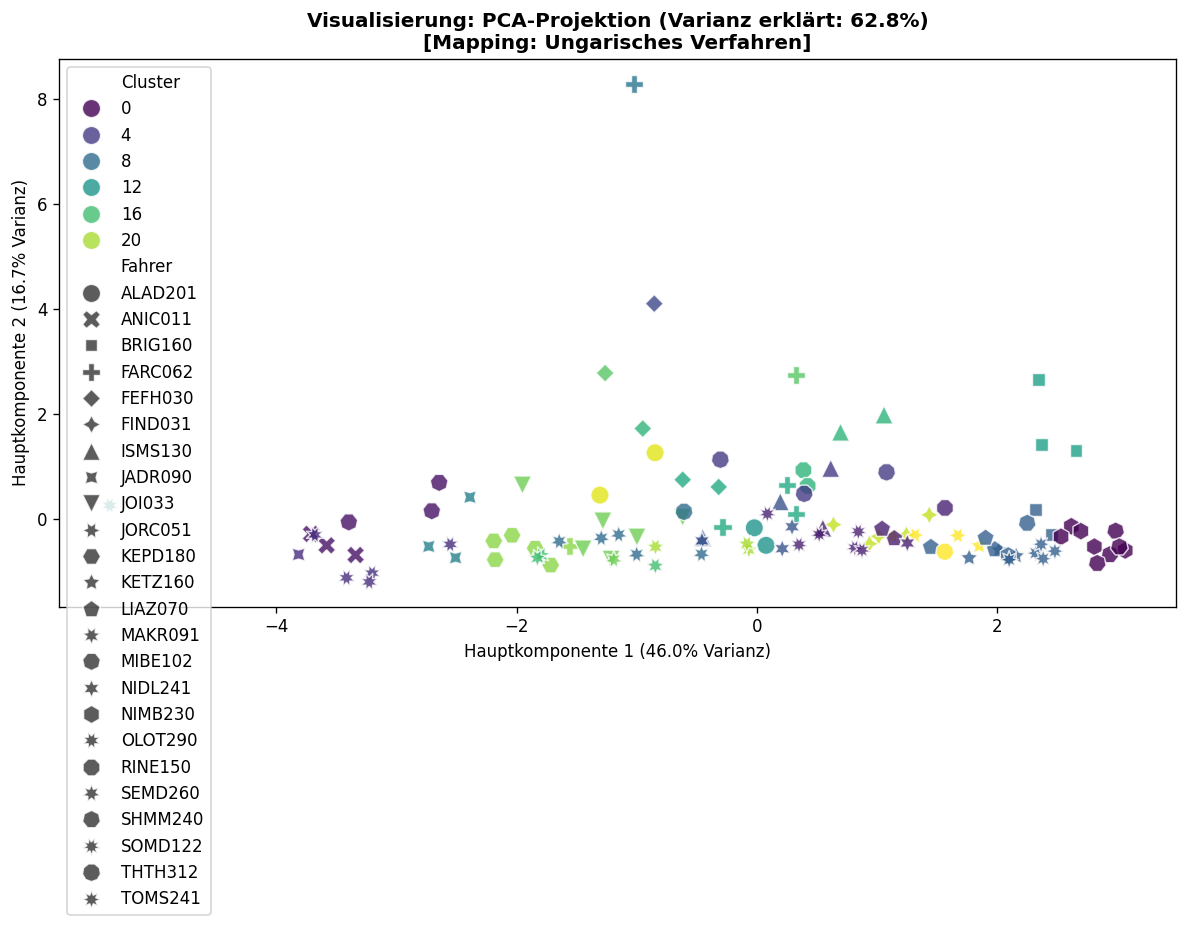

Silhouette Score (Qualität der Trennung): 0.290


In [113]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linear_sum_assignment

try: 
    # 1. Daten vorbereiten (Zusätzliche Sicherheits-Drops, falls die Zelle mehrfach läuft)
    spalten_zum_loeschen = [
        'Fahrer_ID', 'Segment_Nummer', 'Fahrstil_Cluster_ID', 
        'Vorhergesagter_Fahrer', 'Vorhergesagter_Cluster', 'Erkannter_Fahrer'
    ]
    x_clustering = df_master_ml.drop(columns=spalten_zum_loeschen, errors='ignore')

    # 2. Skalieren (WICHTIG für K-Means und PCA!)
    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x_clustering)

    # 3. K-Means Training (Wir nehmen die Anzahl der Fahrer als Cluster-Anzahl)
    num_drivers = df_master_ml['Fahrer_ID'].nunique()
    kmeans_final = KMeans(n_clusters=num_drivers, random_state=42, n_init=1000)
    df_master_ml['Fahrstil_Cluster_ID'] = kmeans_final.fit_predict(x_scaled)

    # ungarische Methode
    contingency_matrix = pd.crosstab(df_master_ml['Fahrer_ID'], df_master_ml['Fahrstil_Cluster_ID'])
    cost_matrix = -contingency_matrix.values
    fahrer_indizes, cluster_indizes = linear_sum_assignment(cost_matrix)

    # konfliktfreie 1-zu-1 Mapping-Wörterbuch befüllen
    cluster_to_driver = {}
    for f_idx, c_idx in zip(fahrer_indizes, cluster_indizes):
        echter_fahrer_name = contingency_matrix.index[f_idx]
        cluster_id = contingency_matrix.columns[c_idx]
        cluster_to_driver[cluster_id] = echter_fahrer_name
        
    # Zuweisung auf das Master-DataFrame anwenden
    df_master_ml['Vorhergesagter_Fahrer'] = df_master_ml['Fahrstil_Cluster_ID'].map(cluster_to_driver)
    
    # PCA zur Visualisierung (Dimensionalitätsreduktion)
    pca = PCA(n_components=2)
    x_pca = pca.fit_transform(x_scaled)
    df_pca = pd.DataFrame(data=x_pca, columns=['PC1', 'PC2'])
    df_pca['Fahrer'] = df_master_ml['Fahrer_ID'].values
    df_pca['Cluster'] = df_master_ml['Fahrstil_Cluster_ID'].values

    # Plotten
    plt.figure(figsize=(10, 7), dpi=120)
    sns.scatterplot(
        data=df_pca,
        x='PC1',
        y='PC2',
        hue='Cluster',
        style='Fahrer',
        palette='viridis',
        s=120,
        alpha=0.8
    )
    
    # Erklärte Varianz anzeigen (sehr wichtig für die Thesis!)
    var_exp = pca.explained_variance_ratio_
    plt.title(f"Visualisierung: PCA-Projektion (Varianz erklärt: {sum(var_exp):.1%})\n[Mapping: Ungarisches Verfahren]", fontweight='bold')
    plt.xlabel(f"Hauptkomponente 1 ({var_exp[0]:.1%} Varianz)")
    plt.ylabel(f"Hauptkomponente 2 ({var_exp[1]:.1%} Varianz)")
    plt.tight_layout()
    plt.show()

    # Score ausgeben
    score = silhouette_score(x_scaled, df_master_ml['Fahrstil_Cluster_ID'])
    print(f"Silhouette Score (Qualität der Trennung): {score:.3f}")

except Exception as e:
    print(f"\n[FAIL] Kritischer Fehler in der AI-Sektion: {e}")

[Daten] Unterricht (Training): 92 Runden
[Daten] Echte Klausur (Test): 24 Runden

--- Ergebnis der Klausur (Ungarisches Verfahren mit GMM) ---
              precision    recall  f1-score   support

     ALAD201       0.00      0.00      0.00         1
     ANIC011       0.00      0.00      0.00         1
     BRIG160       0.00      0.00      0.00         1
     FARC062       0.00      0.00      0.00         1
     FEFH030       0.00      0.00      0.00         1
     FIND031       0.00      0.00      0.00         1
     ISMS130       0.00      0.00      0.00         1
     JADR090       0.00      0.00      0.00         1
      JOI033       0.00      0.00      0.00         1
     JORC051       0.00      0.00      0.00         1
     KEPD180       1.00      1.00      1.00         1
     KETZ160       0.00      0.00      0.00         1
     LIAZ070       0.00      0.00      0.00         1
     MAKR091       0.00      0.00      0.00         1
     MIBE102       0.00      0.00      0.00   

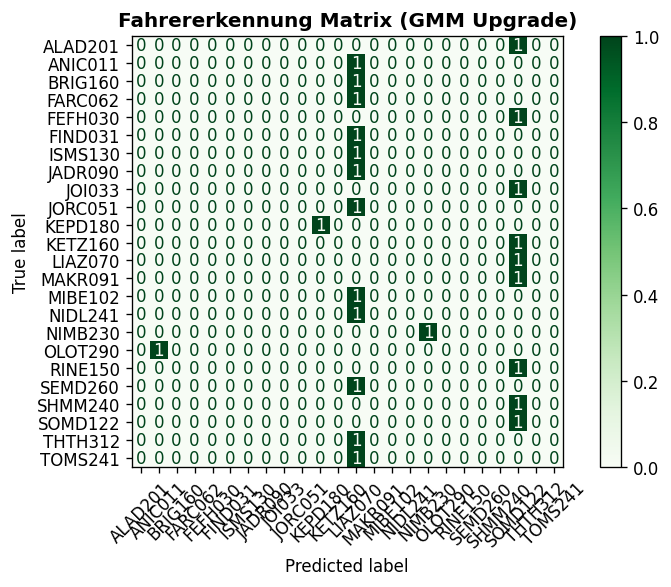

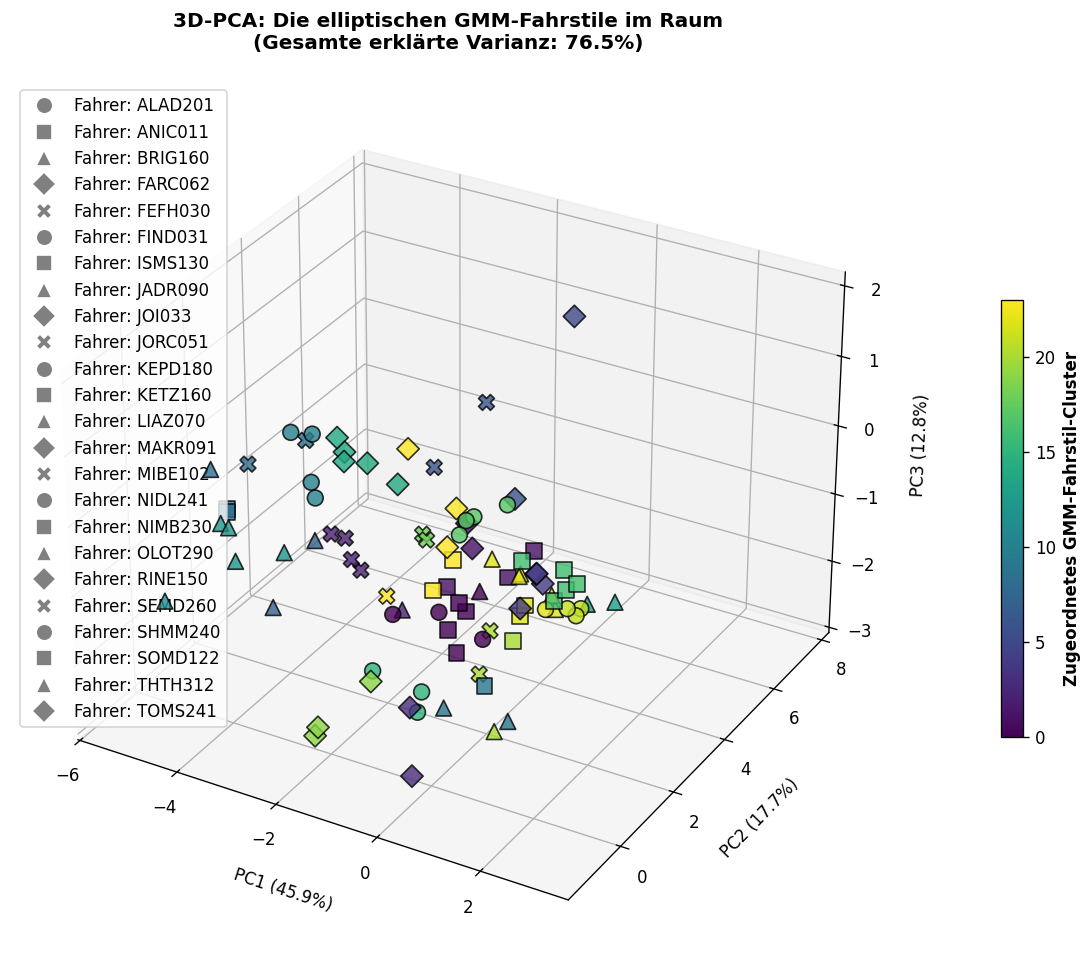

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import numpy as np
from scipy.optimize import linear_sum_assignment

try:
    # --- JEDER Fahrer hat exakt 6 Runden insgesamt ---
    # Wir ziehen von jedem Fahrer genau 1 ungesehene Runden für die Klausur
    test_df = df_master_ml.groupby('Fahrer_ID').sample(n=1, random_state=42).copy()
    
    # Die restlichen 4 Runden pro Fahrer wandern ins Training
    train_df = df_master_ml.drop(test_df.index).copy()
    
    print(f"[Daten] Unterricht (Training): {len(train_df)} Runden")
    print(f"[Daten] Echte Klausur (Test): {len(test_df)} Runden")

    # Datenentfernung für die reine Feature-Matrix
    spalten_zum_loeschen = [
        'Fahrer_ID', 
        'Segment_Nummer', 
        'Fahrstil_Cluster_ID', 
        'Vorhergesagter_Fahrer',
        'Vorhergesagter_Cluster',
        'Erkannter_Fahrer',
        'Cluster_ID'
    ]
    
    X_train = train_df.drop(columns=spalten_zum_loeschen, errors='ignore')
    X_test = test_df.drop(columns=spalten_zum_loeschen, errors='ignore')

    # Skalieren
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test) 

    # Training (K-Means sucht nach den 5 Fahrstilen im 8D-Raum)
    num_drivers = train_df['Fahrer_ID'].nunique()  
    kmeans = KMeans(
        n_clusters=num_drivers, 
        random_state=42, 
        n_init=100,
    )
    train_df['Cluster_ID'] = kmeans.fit_predict(X_train_scaled)

    # ungarische Methode
    contingency_matrix = pd.crosstab(train_df['Fahrer_ID'], train_df['Cluster_ID'])
    cost_matrix = -contingency_matrix.values
    fahrer_indizes, cluster_indizes = linear_sum_assignment(cost_matrix)

    cluster_zu_fahrer = {}
    for f_idx, c_idx in zip(fahrer_indizes, cluster_indizes):
        echter_fahrer_name = contingency_matrix.index[f_idx]
        cluster_id = contingency_matrix.columns[c_idx]
        cluster_zu_fahrer[cluster_id] = echter_fahrer_name

    # Vorhersage auf den ungesehenen Runden pro Fahrer
    test_df['Vorhergesagter_Cluster'] = kmeans.predict(X_test_scaled)
    test_df['Erkannter_Fahrer'] = test_df['Vorhergesagter_Cluster'].map(cluster_zu_fahrer)

    y_true_test = test_df['Fahrer_ID']
    y_pred_test = test_df['Erkannter_Fahrer']
    
    print("\n--- Ergebnis der Klausur (Ungarisches Verfahren) ---")
    print(classification_report(y_true_test, y_pred_test, zero_division=0))

    # --- GRAFIK 1: Confusion Matrix ---
    cm = confusion_matrix(y_true_test, y_pred_test)
    labels = sorted(y_true_test.unique())
    
    fig1, ax1 = plt.subplots(figsize=(7, 5), dpi=120)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax1, cmap=plt.cm.Greens, xticks_rotation=45)
    plt.title("Fahrererkennung Matrix", fontweight='bold')
    plt.tight_layout()
    plt.show()

    # --- GRAFIK 2: Der 3-Dimensionale Fahrstil-Raum (3D-PCA) ---
    pca_3d = PCA(n_components=3)
    X_train_pca = pca_3d.fit_transform(X_train_scaled)
    
    fig2 = plt.figure(figsize=(10, 8), dpi=120)
    ax2 = fig2.add_subplot(111, projection='3d')
    
    markers = ['o', 's', '^', 'D', 'X']
    vmin = train_df['Cluster_ID'].min()
    vmax = train_df['Cluster_ID'].max()
    
    # Plotten der Punkte im Raum (Farbe = Cluster, Form = Echter Fahrer)
    for i, fahrer in enumerate(sorted(train_df['Fahrer_ID'].unique())):
        mask = train_df['Fahrer_ID'] == fahrer
        ax2.scatter(
            X_train_pca[mask, 0], 
            X_train_pca[mask, 1], 
            X_train_pca[mask, 2],
            c=train_df.loc[mask, 'Cluster_ID'], 
            cmap='viridis', 
            marker=markers[i % len(markers)],
            s=90, 
            vmin=vmin, 
            vmax=vmax,
            edgecolor='k',
            alpha=0.8
        )
    
    # Farbskala für die Cluster hinzufügen
    mappable = plt.cm.ScalarMappable(cmap='viridis')
    mappable.set_array(train_df['Cluster_ID'])
    cbar = fig2.colorbar(mappable, ax=ax2, pad=0.1, shrink=0.5)
    cbar.set_label('Zugeordnetes Fahrstil-Cluster (0-4)', fontweight='bold')
    
    # Achsenbeschriftung mit der exakt erklärten Varianz der Hauptkomponenten
    var_exp = pca_3d.explained_variance_ratio_
    ax2.set_title(f"3D-PCA: Die 5 Fahrstile im Raum\n(Gesamte erklärte Varianz: {sum(var_exp):.1%})", fontweight='bold', pad=20)
    ax2.set_xlabel(f"PC1 ({var_exp[0]:.1%})", labelpad=10)
    ax2.set_ylabel(f"PC2 ({var_exp[1]:.1%})", labelpad=10)
    ax2.set_zlabel(f"PC3 ({var_exp[2]:.1%})", labelpad=10)
    
    # Saubere Legende für die echten Fahrer-IDs bauen
    legend_elements = [
        Line2D([0], [0], marker=markers[i % len(markers)], color='w', 
               markerfacecolor='gray', markersize=10, label=f"Fahrer: {fahrer}")
        for i, fahrer in enumerate(sorted(train_df['Fahrer_ID'].unique()))
    ]
    ax2.legend(handles=legend_elements, loc='upper left')
    
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"\n[FAIL] Kritischer Fehler im Test-Modul: {e}")